In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Modellerin sonuçlarını tutacağımız listeler
trained_models = {}
metrics = []

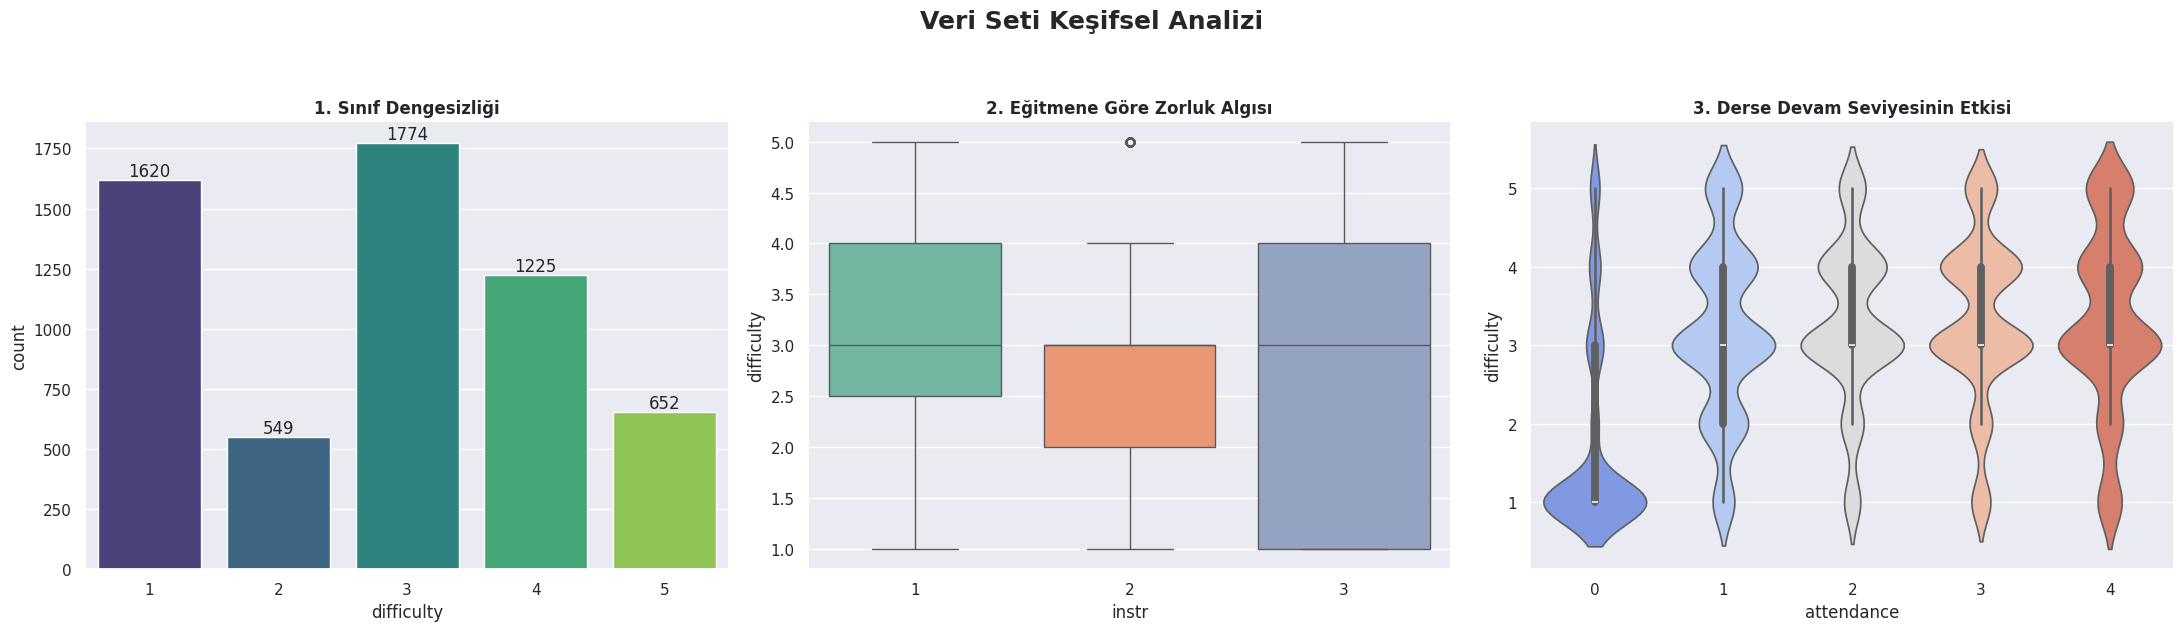

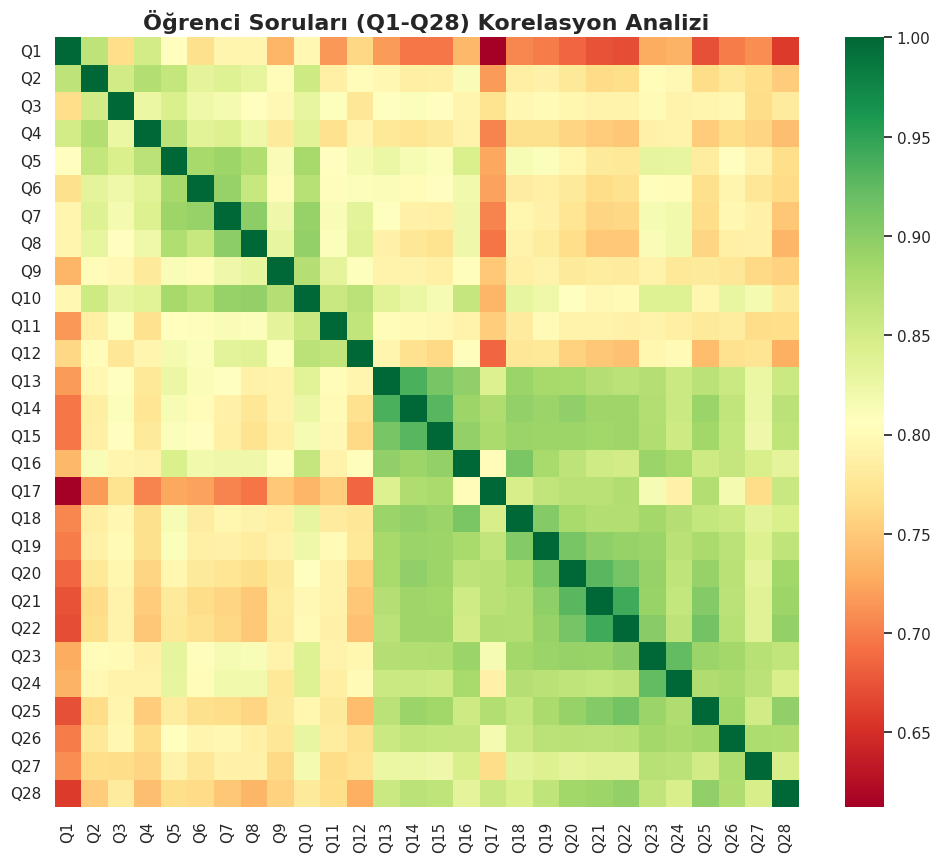

In [2]:
# Veriyi Yükle
df = pd.read_csv('turkiye-student-evaluation_generic.csv')

# --- GRAFİK 1: 3'LÜ PANEL (VERİ HİKAYESİ) ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Veri Seti Keşifsel Analizi', fontsize=18, fontweight='bold', y=1.05)

sns.countplot(x='difficulty', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('1. Sınıf Dengesizliği', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.boxplot(x='instr', y='difficulty', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('2. Eğitmene Göre Zorluk Algısı', fontweight='bold')

sns.violinplot(x='attendance', y='difficulty', data=df, palette='coolwarm', ax=axes[2])
axes[2].set_title('3. Derse Devam Seviyesinin Etkisi', fontweight='bold')
plt.tight_layout()
plt.show()

# --- GRAFİK 2: KORELASYON ANALİZİ ---
plt.figure(figsize=(12, 10))
corr_matrix = df.loc[:, 'Q1':'Q28'].corr()
sns.heatmap(corr_matrix, cmap='RdYlGn', annot=False)
plt.title('Öğrenci Soruları (Q1-Q28) Korelasyon Analizi', fontsize=16, fontweight='bold')
plt.show()

In [3]:
X_questions = df[[f'Q{i}' for i in range(1, 29)]]
X_meta = df[['instr', 'class', 'nb.repeat', 'attendance']]
y = df['difficulty']

# Soruları Ölçeklendirme ve PCA
scaler_q = StandardScaler()
X_questions_scaled = scaler_q.fit_transform(X_questions)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_questions_scaled)

pca_col_names = [f'PCA_{i+1}' for i in range(X_pca.shape[1])]
X_combined = pd.concat([X_meta.reset_index(drop=True), pd.DataFrame(X_pca, columns=pca_col_names)], axis=1)

# Bölme ve Ölçeklendirme
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)
scaler_final = StandardScaler()
X_train = scaler_final.fit_transform(X_train_raw)
X_test = scaler_final.transform(X_test_raw)

# Öğrenme eğrisi için tüm veriyi ölçeklendir
X_final_scaled = scaler_final.fit_transform(X_combined)

# DataFrame'e geri çevir (Etiketleri kaybetmemek için)
X_train = pd.DataFrame(X_train, columns=X_combined.columns)
X_test = pd.DataFrame(X_test, columns=X_combined.columns)

# ROC eğrisi için binarize işlemleri
classes_in_y = sorted(np.unique(y))
y_test_bin = label_binarize(y_test, classes=classes_in_y)
n_classes = y_test_bin.shape[1]

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (4656, 9)
Test seti boyutu: (1164, 9)


In [5]:
def train_and_evaluate(model, name):
    # Model Eğitimi
    model.fit(X_train, y_train)
    trained_models[name] = model
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')

    metrics.append({'Model': name, 'Doğruluk Oranı': acc, 'F1 Skoru': f1})
    print(f"[{name}] -> Doğruluk: {acc:.4f} | F1 Skoru: {f1:.4f}")

    # Grafik Paneli Çizimi
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{name} - Model Analiz Paneli', fontsize=20, fontweight='bold', y=0.98)

    # 1. Karmaşıklık Matrisi
    cm = confusion_matrix(y_test, preds, labels=classes_in_y)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], xticklabels=classes_in_y, yticklabels=classes_in_y)
    axes[0, 0].set_title(f'{name} Karmaşıklık Matrisi', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Tahmin Edilen')
    axes[0, 0].set_ylabel('Gerçek')

    # 2. ROC Eğrisi
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
        for i, color in zip(range(n_classes), colors):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            axes[0, 1].plot(fpr, tpr, color=color, lw=2, label=f'Sınıf {classes_in_y[i]} (AUC={auc(fpr, tpr):.2f})')
        axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[0, 1].legend(loc="lower right")
    else:
        axes[0, 1].text(0.5, 0.5, 'ROC Desteklenmiyor', ha='center', va='center', fontsize=14)
    axes[0, 1].set_title(f'{name} Çok Sınıflı ROC Eğrisi', fontsize=14, fontweight='bold')

    # 3. Önemli Parametreler
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        result = permutation_importance(model, X_test, y_test, n_repeats=3, random_state=42)
        importances = result.importances_mean
    indices = np.argsort(importances)[::-1][:10]
    sns.barplot(x=importances[indices], y=X_combined.columns[indices], palette='magma', ax=axes[1, 0])
    axes[1, 0].set_title(f'{name} En Önemli 10 Parametre (PCA)', fontsize=14, fontweight='bold')

    # 4. Öğrenme Eğrisi (Artık her model için çiziliyor)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_final_scaled, y, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    axes[1, 1].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Eğitim")
    axes[1, 1].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Test")
    axes[1, 1].set_title(f'{name} Öğrenme Eğrisi', fontsize=14, fontweight='bold', color='darkred')
    axes[1, 1].legend(loc="best")
    axes[1, 1].set_xlabel('Eğitim Verisi Boyutu')
    axes[1, 1].set_ylabel('Skor')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

[Rastgele Orman] -> Doğruluk: 0.4570 | F1 Skoru: 0.4591


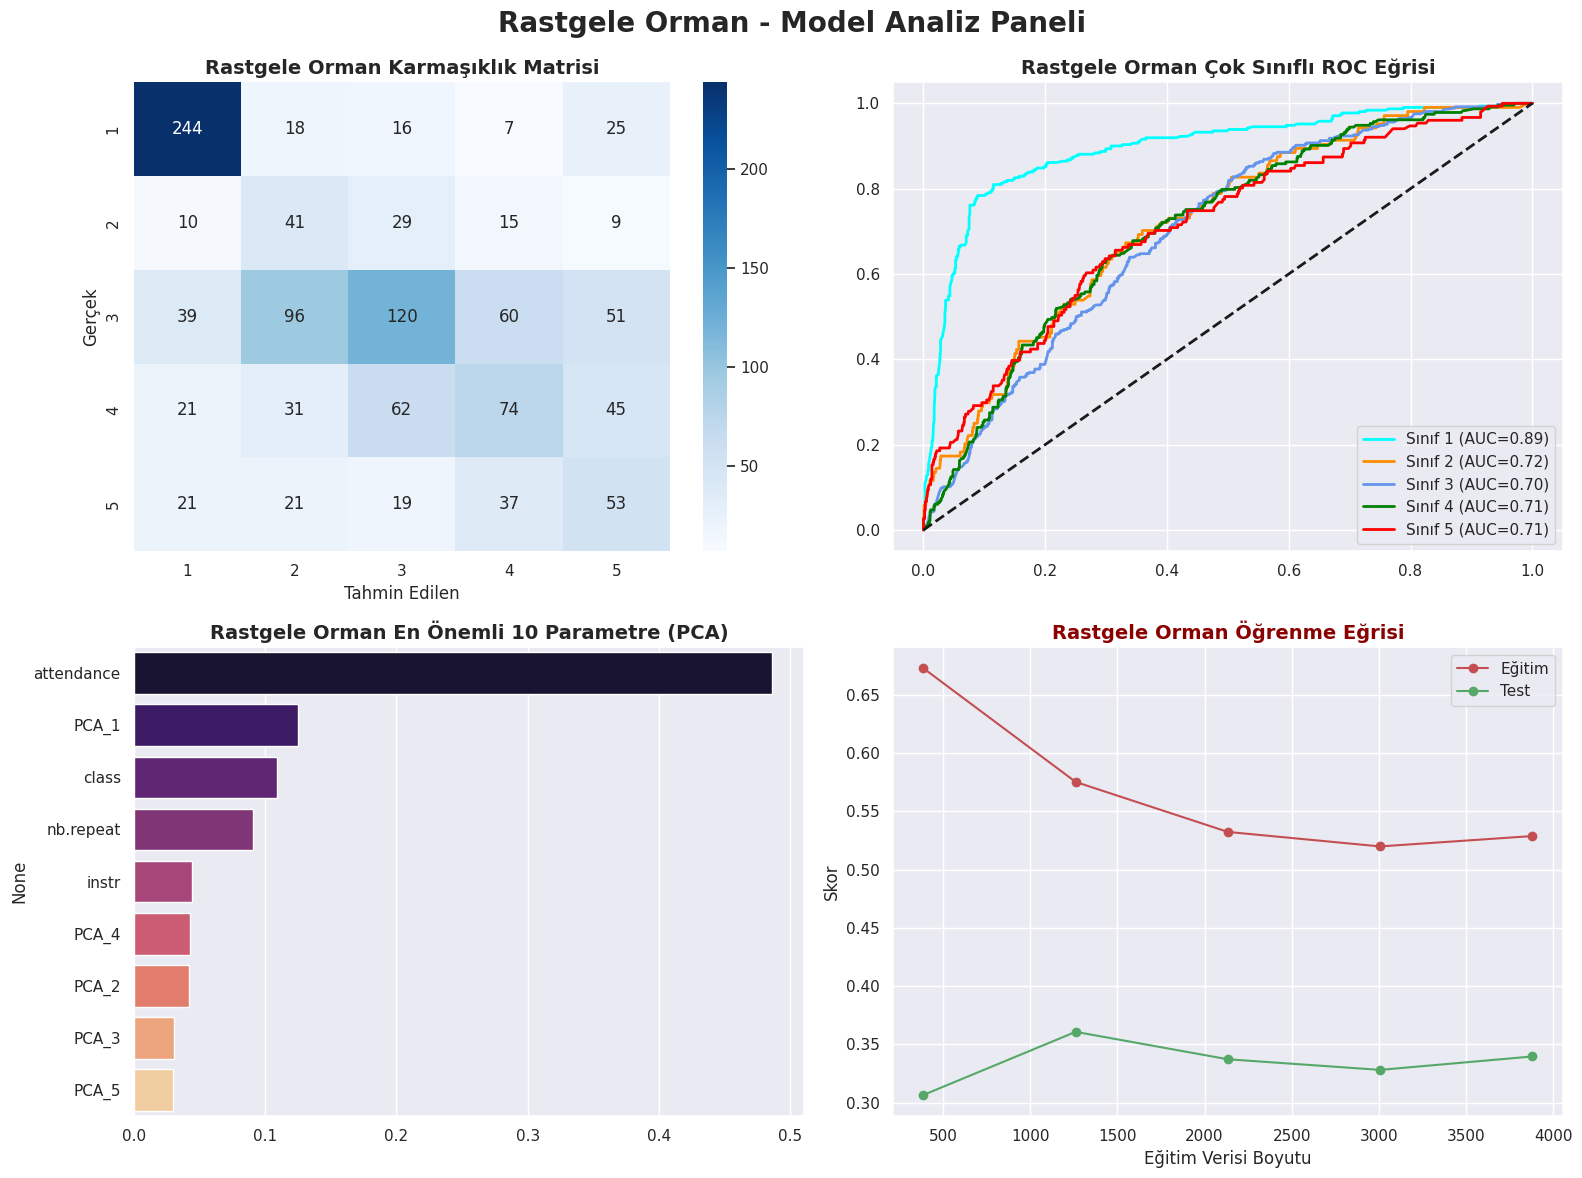

In [6]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, class_weight='balanced')
train_and_evaluate(rf_model, 'Rastgele Orman')

[Karar Ağacı] -> Doğruluk: 0.4613 | F1 Skoru: 0.4625


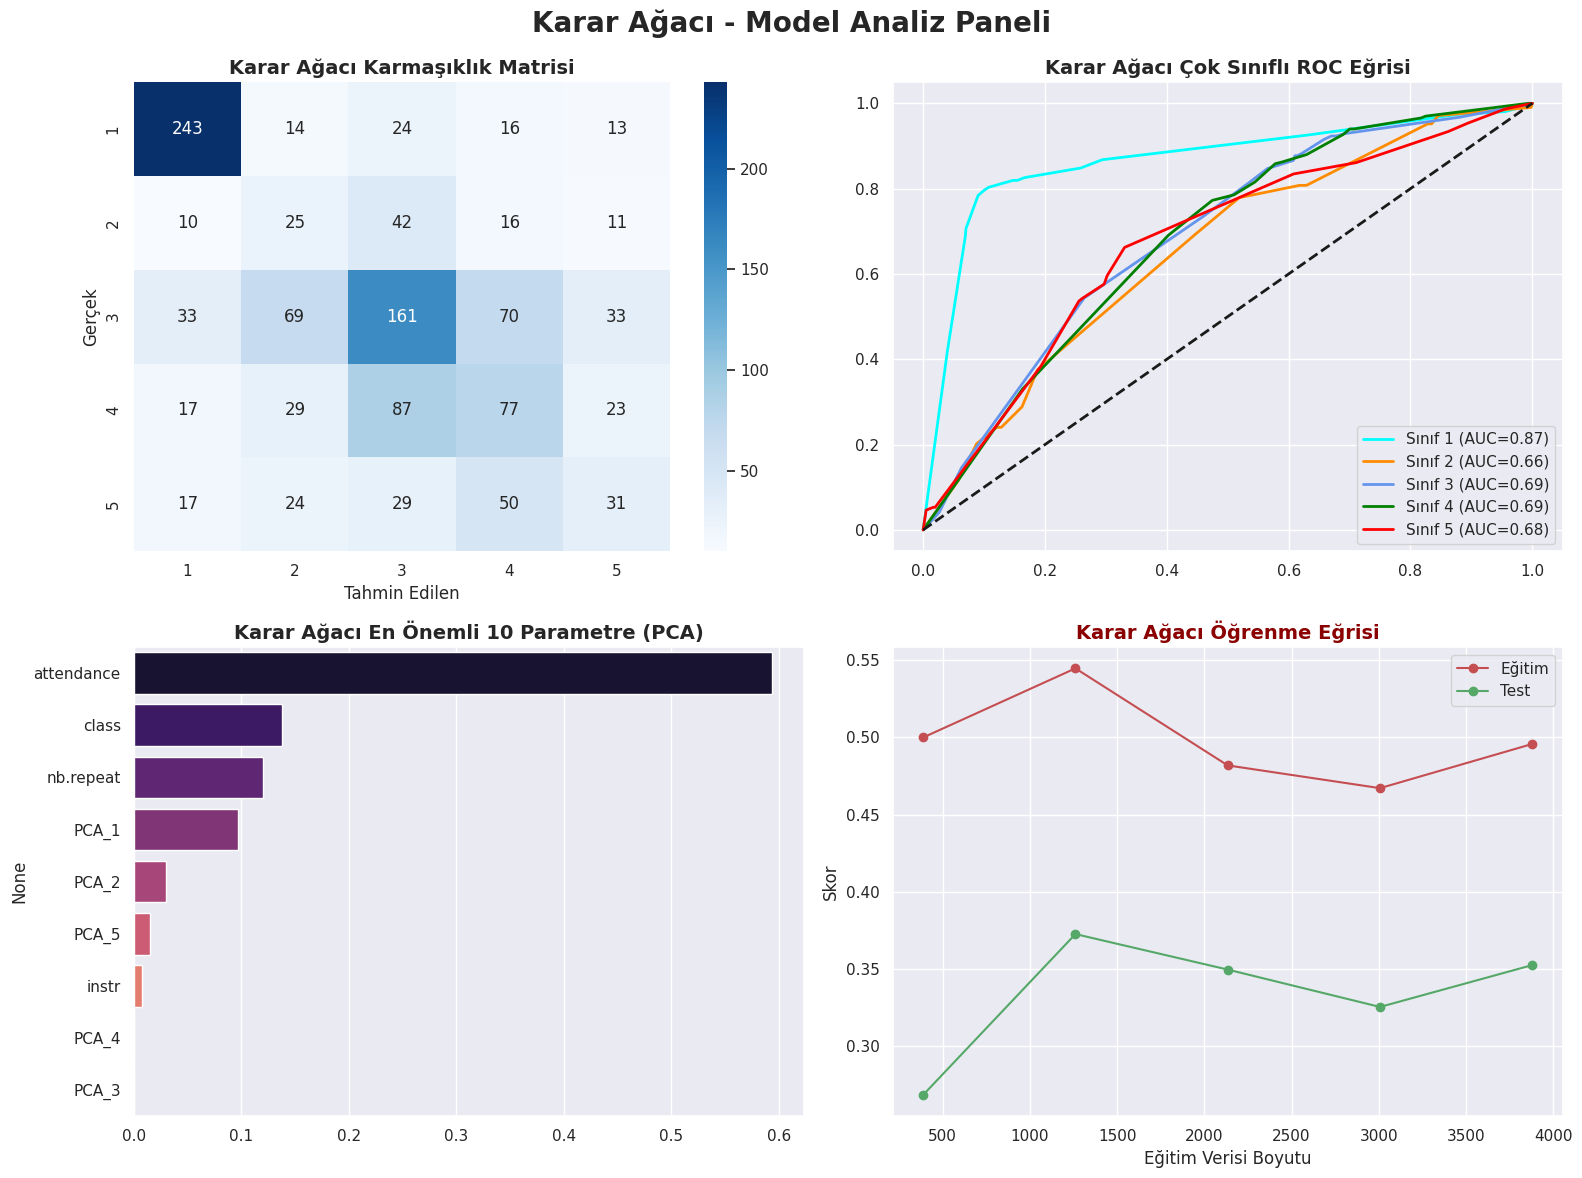

In [7]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
train_and_evaluate(dt_model, 'Karar Ağacı')

[KNN] -> Doğruluk: 0.4716 | F1 Skoru: 0.4352


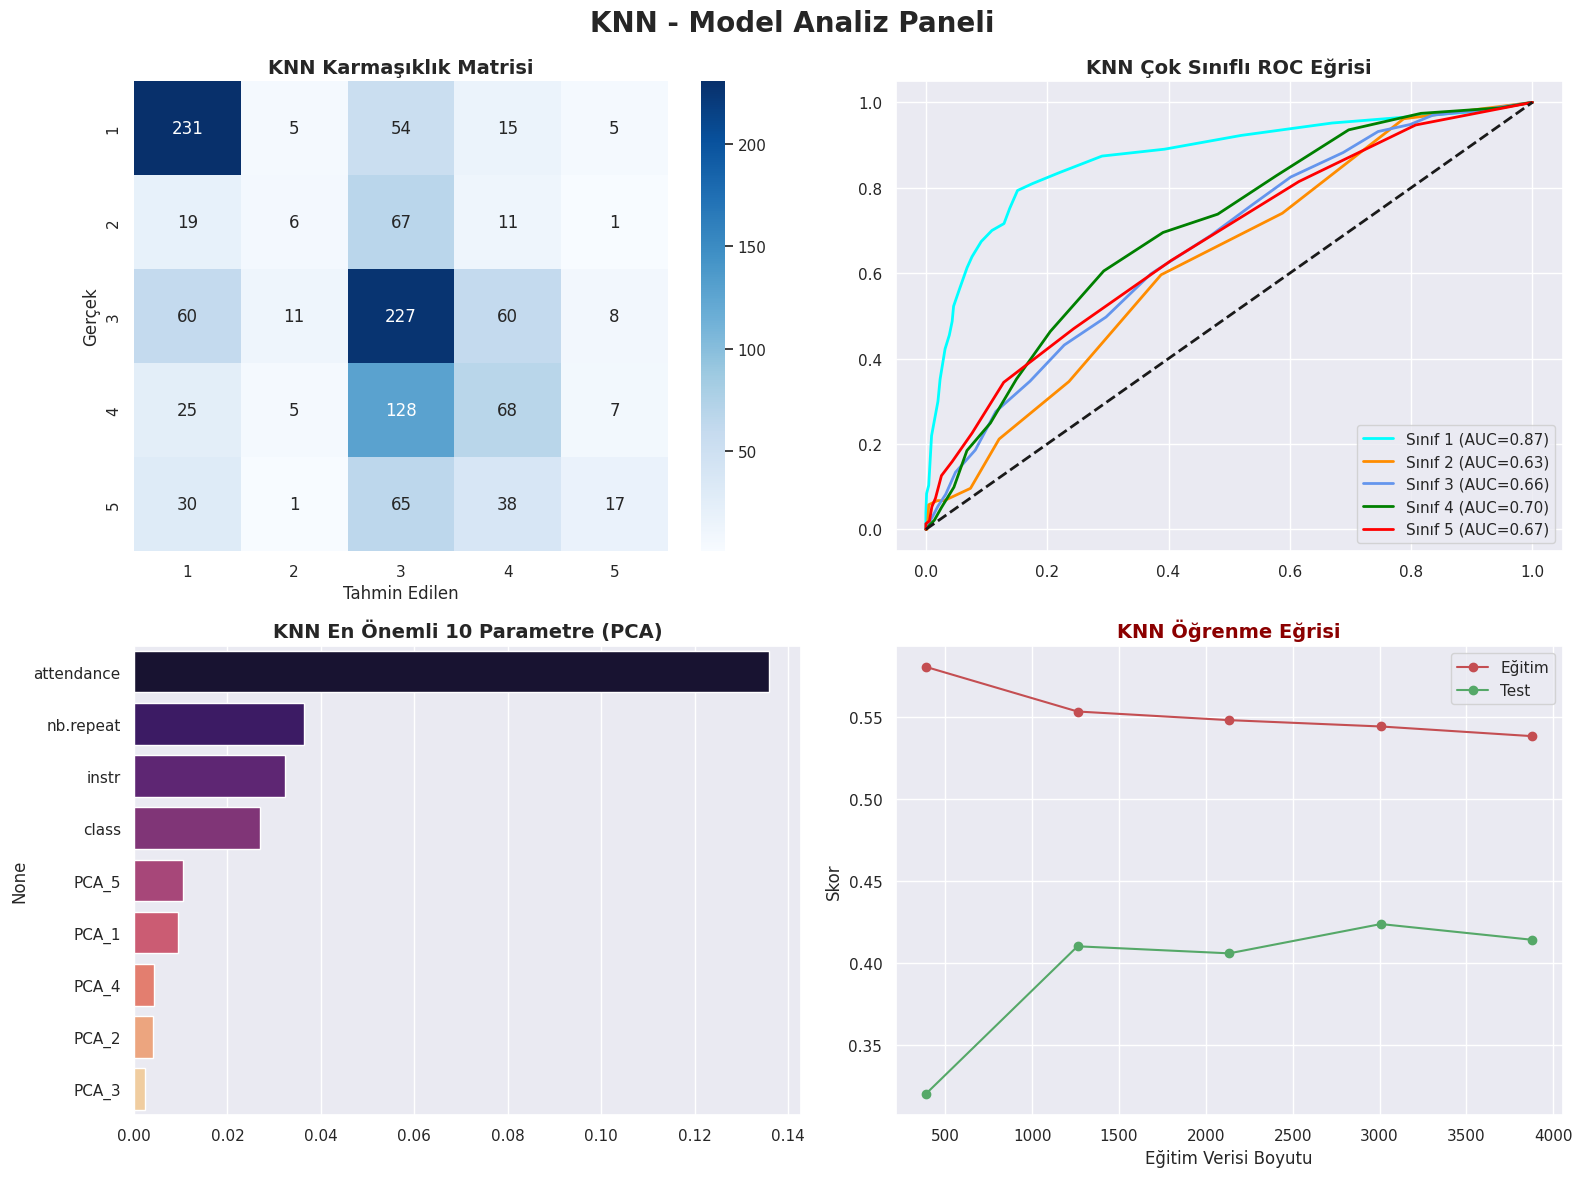

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=25)
train_and_evaluate(knn_model, 'KNN')

[Lojistik Reg.] -> Doğruluk: 0.4124 | F1 Skoru: 0.3990


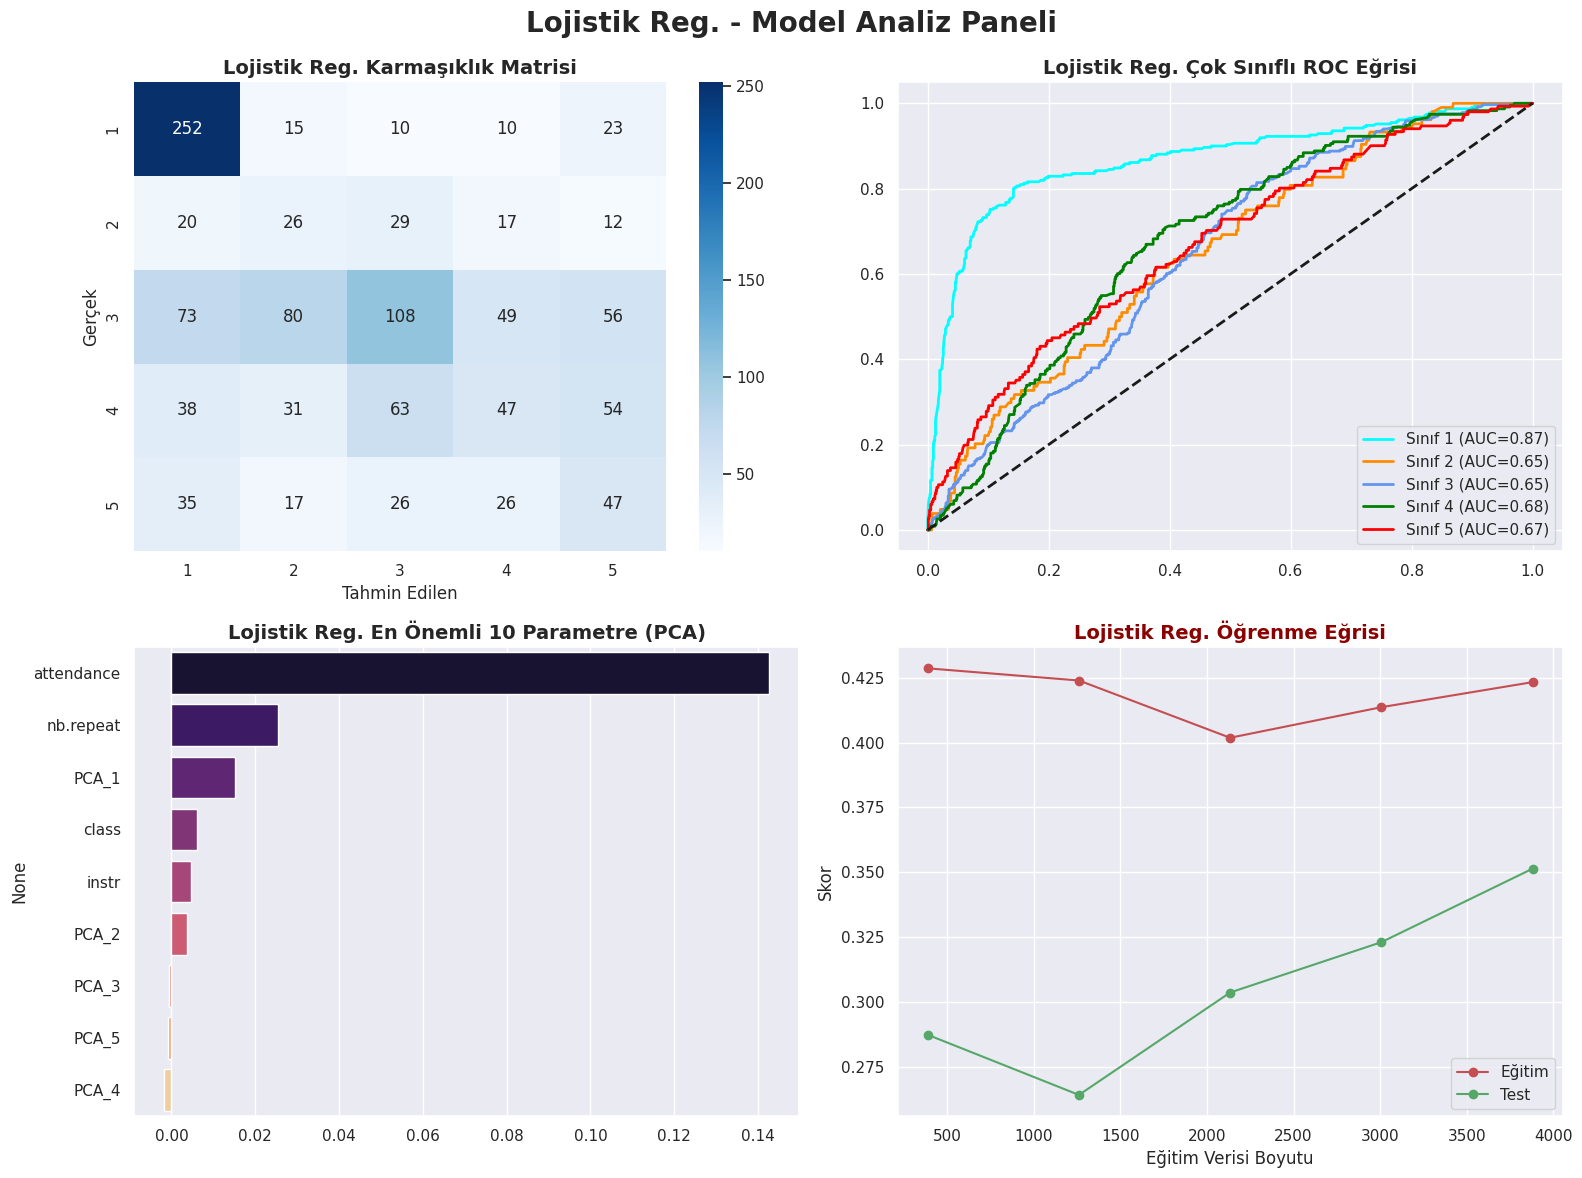

In [9]:
log_model = LogisticRegression(C=0.05, max_iter=2000, random_state=42, class_weight='balanced')
train_and_evaluate(log_model, 'Lojistik Reg.')

[Basit Bayes] -> Doğruluk: 0.4175 | F1 Skoru: 0.3592


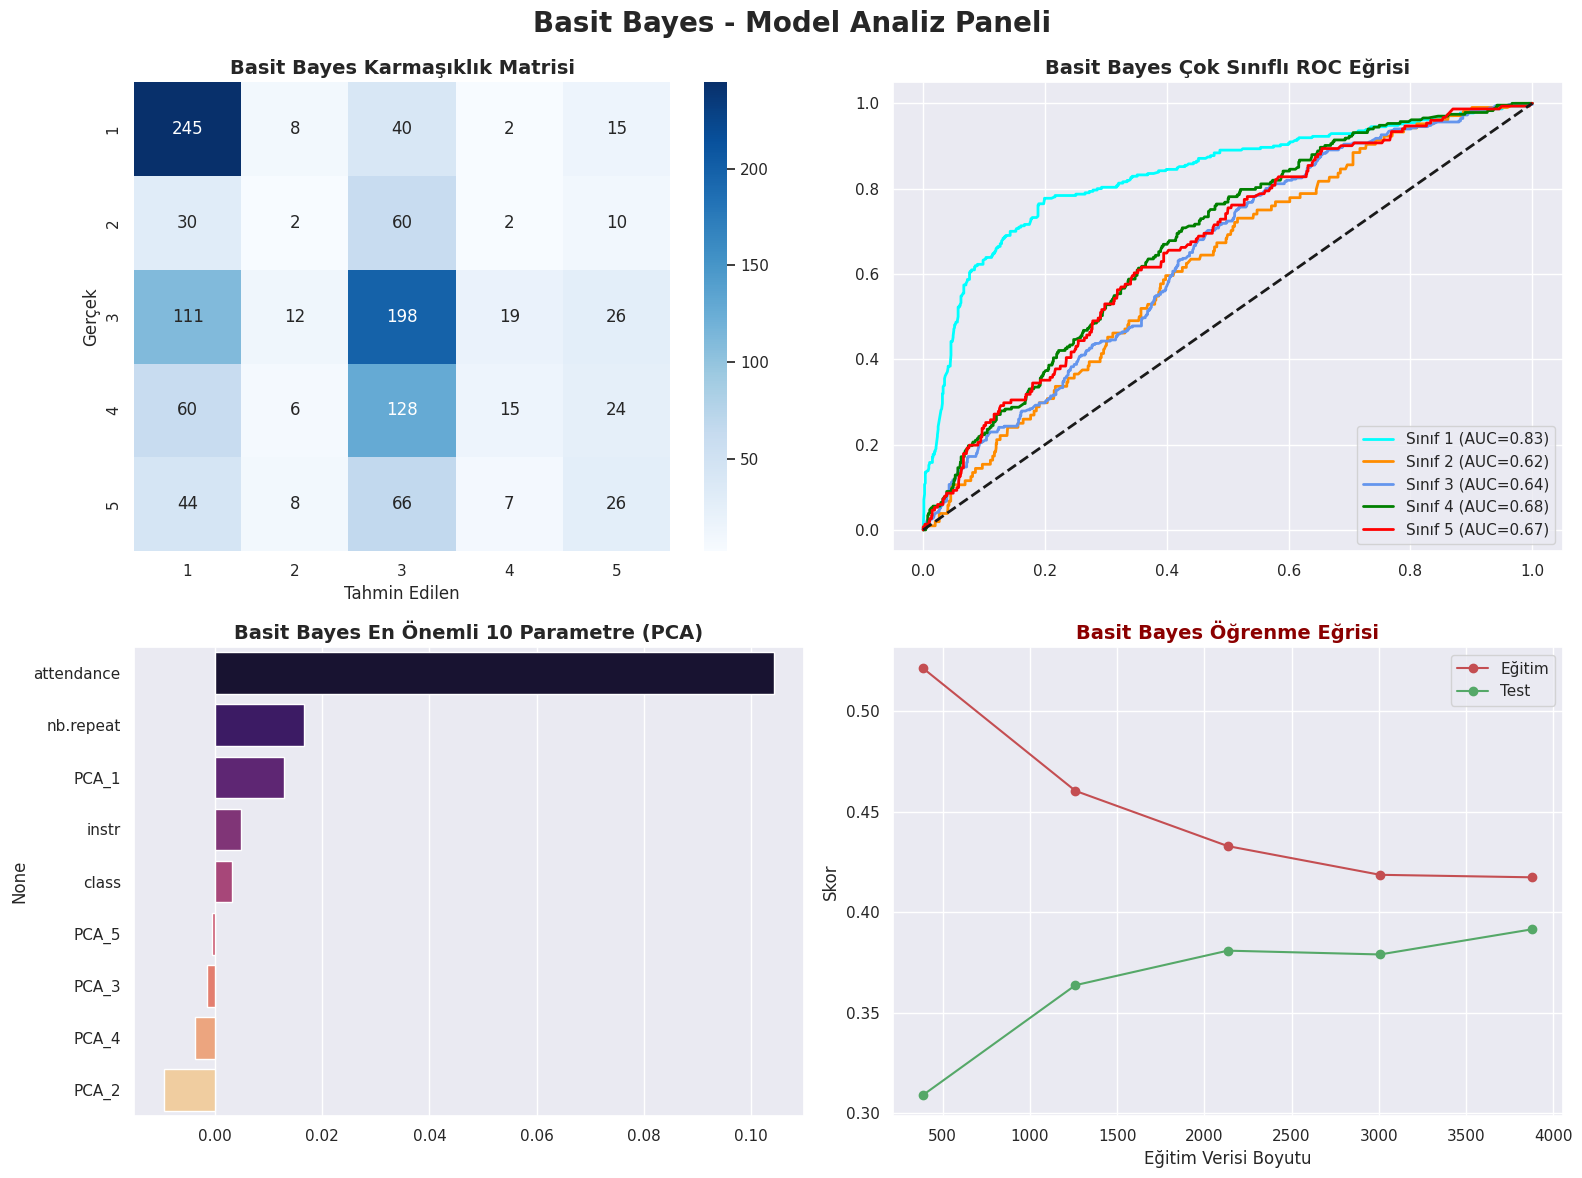

In [10]:
nb_model = GaussianNB()
train_and_evaluate(nb_model, 'Basit Bayes')

[YSA] -> Doğruluk: 0.5112 | F1 Skoru: 0.4687


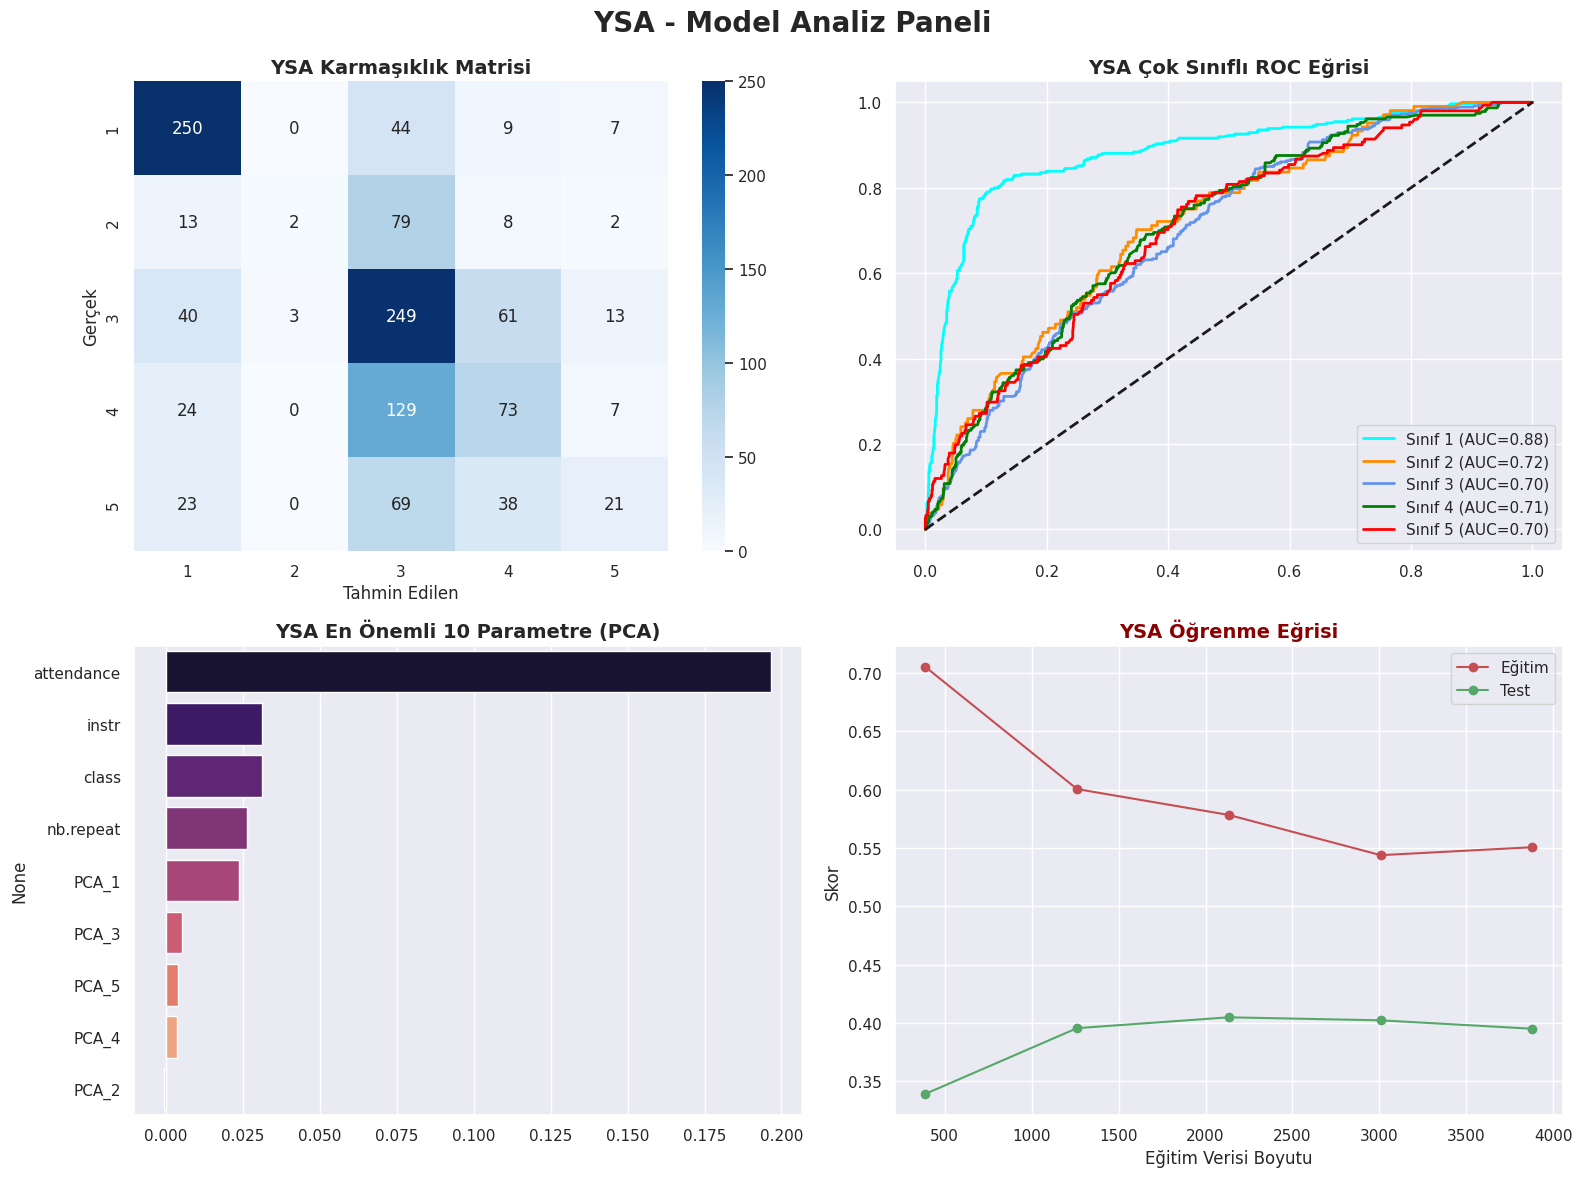

In [11]:
mlp_model = MLPClassifier(hidden_layer_sizes=(30,), alpha=0.5, max_iter=2000, random_state=42)
train_and_evaluate(mlp_model, 'YSA')

[SVM] -> Doğruluk: 0.4296 | F1 Skoru: 0.4337


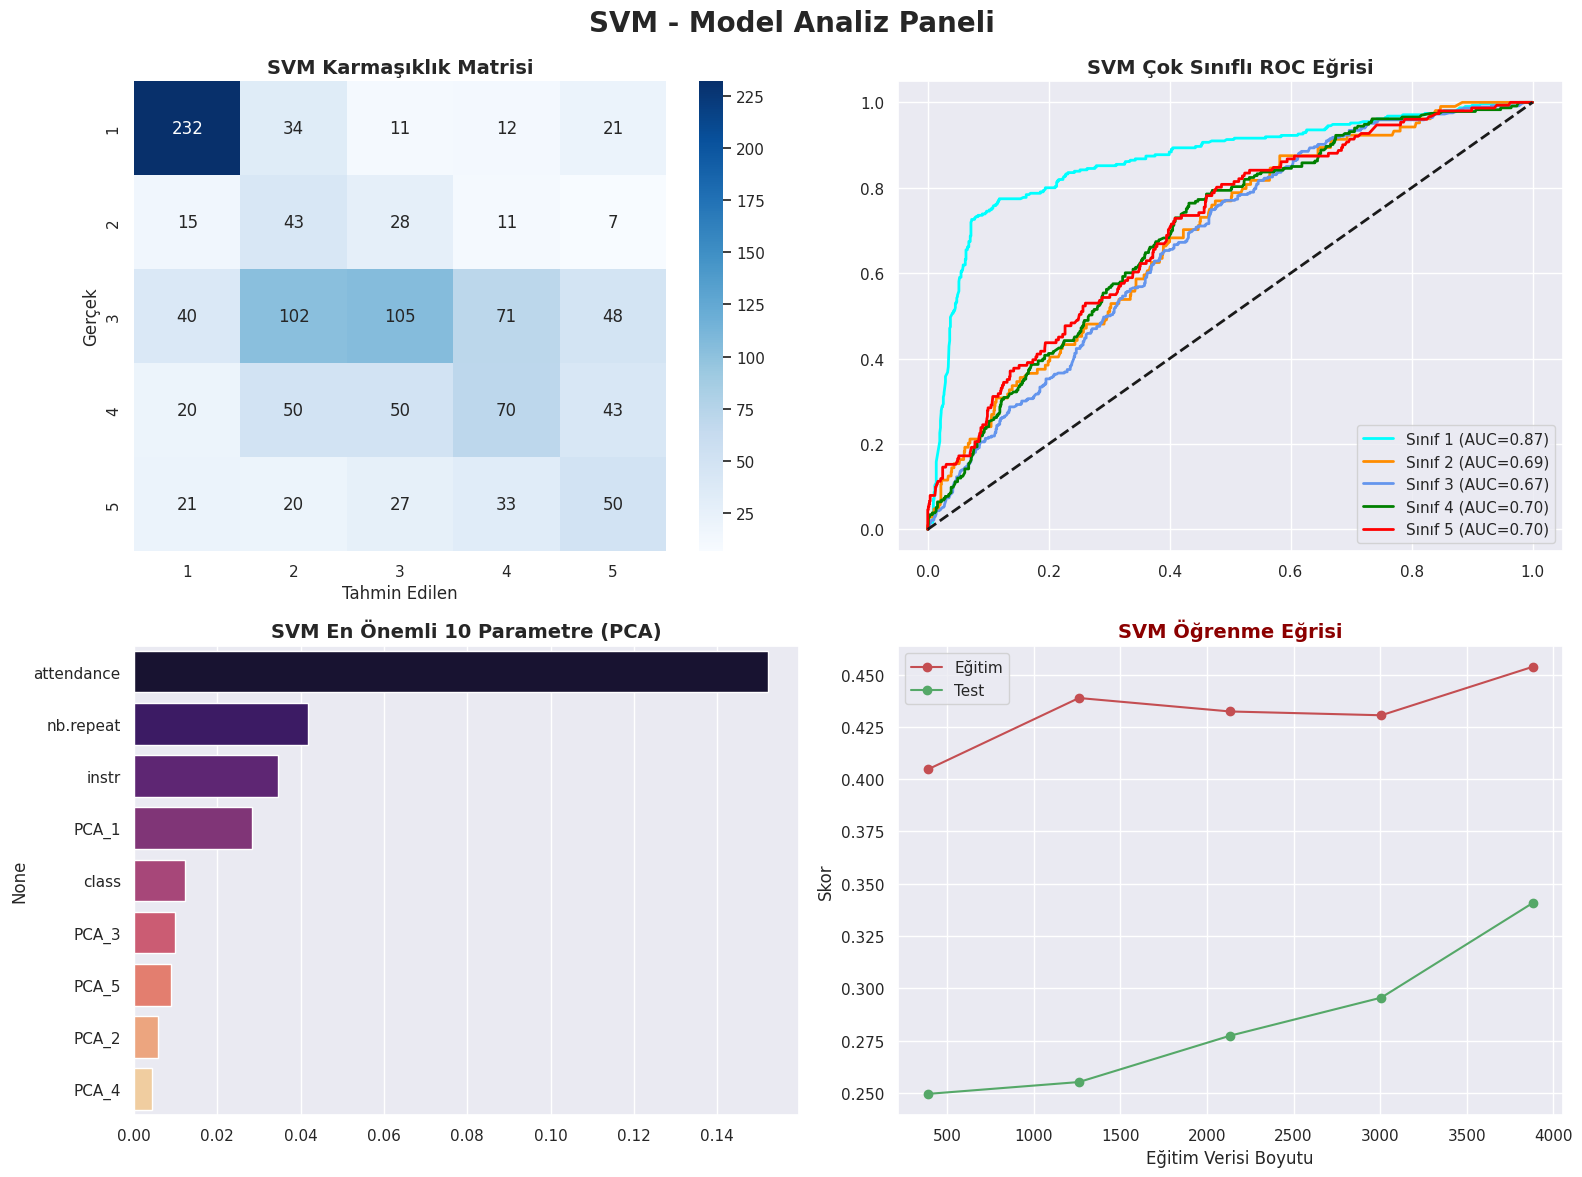

In [12]:
svm_model = SVC(C=0.1, probability=True, random_state=42, class_weight='balanced')
train_and_evaluate(svm_model, 'SVM')


MODEL ADI                 | DOĞRULUK   | F1 SKORU  
------------------------------------------------------------
YSA                       | 0.5112     | 0.4687    
Karar Ağacı               | 0.4613     | 0.4625    
Rastgele Orman            | 0.4570     | 0.4591    
KNN                       | 0.4716     | 0.4352    
SVM                       | 0.4296     | 0.4337    
Lojistik Reg.             | 0.4124     | 0.3990    
Basit Bayes               | 0.4175     | 0.3592    



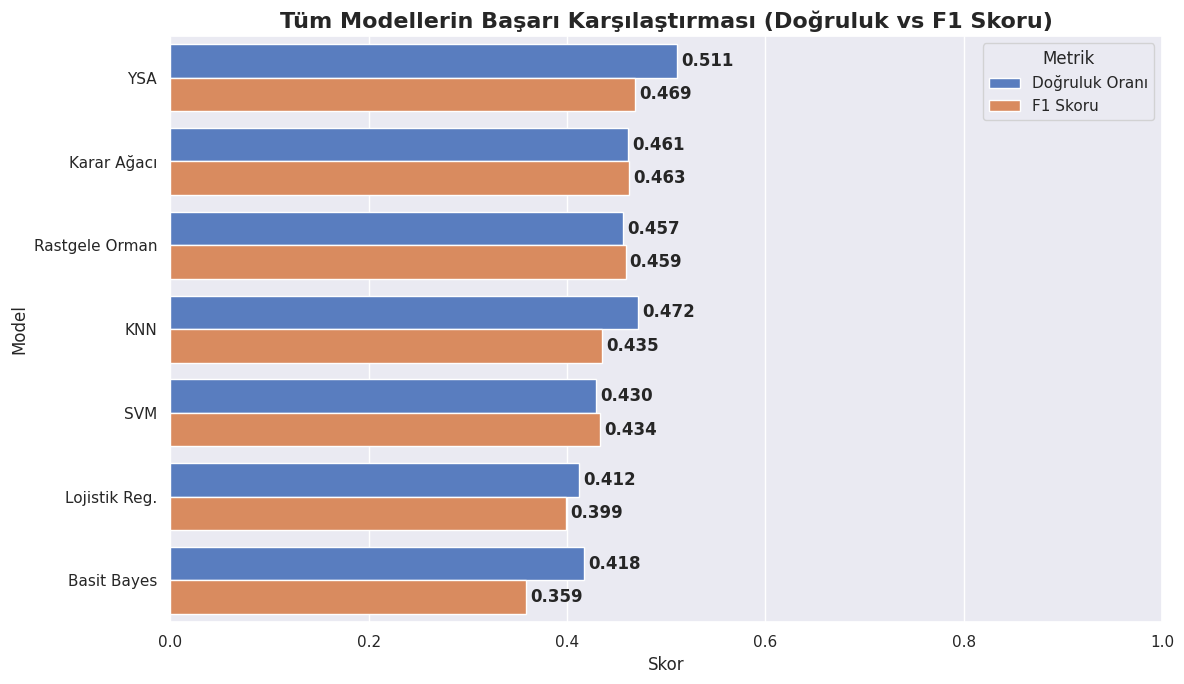


EN İYİ MODEL: YSA (F1 Skoru: 0.4687)


In [13]:
# Sonuçları DataFrame'e çevir ve F1 Skoruna göre sırala
results_df = pd.DataFrame(metrics).sort_values(by='F1 Skoru', ascending=False)
results_df.drop_duplicates(subset=['Model'], keep='last', inplace=True) # Aynı model iki kez çalıştırılırsa sonuncuyu tut

print("\n" + "="*60)
print(f"{'MODEL ADI':<25} | {'DOĞRULUK':<10} | {'F1 SKORU':<10}")
print("-" * 60)
for index, row in results_df.iterrows():
    print(f"{row['Model']:<25} | {row['Doğruluk Oranı']:<10.4f} | {row['F1 Skoru']:<10.4f}")
print("="*60 + "\n")

# --- GRAFİK: MODEL BAŞARI KIYASLAMA ---
plt.figure(figsize=(12, 7))
results_melted = results_df.melt(id_vars='Model', value_vars=['Doğruluk Oranı', 'F1 Skoru'], var_name='Metrik', value_name='Skor')

ax = sns.barplot(x='Skor', y='Model', hue='Metrik', data=results_melted, palette='muted')
plt.title('Tüm Modellerin Başarı Karşılaştırması (Doğruluk vs F1 Skoru)', fontsize=16, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontweight='bold')

plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

print(f"\nEN İYİ MODEL: {results_df.iloc[0]['Model']} (F1 Skoru: {results_df.iloc[0]['F1 Skoru']:.4f})")

In [ ]:
# Ortak model
from sklearn.ensemble import VotingClassifier

# YSA'nın da dahil olduğu Genişletilmiş model
# Bilgisayar çökmesin diye n_jobs=1 yaptık!
voting_clf_v2 = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('svm', svm_model),
        ('log', log_model),
        ('ysa', mlp_model)
    ],
    voting='soft',
    n_jobs=1
)

train_and_evaluate(voting_clf_v2, 'YSA Destekli Model')